# Librairies and data

In [1]:
from torch.utils.data import DataLoader

import os, time, datetime

import sys
sys.path.append('../../py_scripts')

from SPAC_Dataset import dataset
from models import *

## T2T

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib.patches import ConnectionPatch
import matplotlib.colors as plc
import cooler
import string
from numpy.lib.stride_tricks import as_strided


good_gid = "HG002.H1"
err_gid = "HG002.C2B" # Deletions

good_cool = cooler.Cooler(f"/home/amergez/SPA-C/datasets_v2/{good_gid}/aligned/{good_gid}.JHE.mcool::/resolutions/5000")
good_mat = good_cool.matrix(balance=False)
good_cool_big = cooler.Cooler(f"/home/amergez/SPA-C/datasets_v2/{good_gid}/aligned/{good_gid}.JHE.mcool::/resolutions/1000000")
good_mat_big = good_cool_big.matrix(balance=False)
err_cool = cooler.Cooler(f"/home/amergez/SPA-C/datasets_v2/{err_gid}/aligned/{err_gid}.JHE.mcool::/resolutions/5000")
err_mat = err_cool.matrix(balance=False)

def parse_matrices(ctg1, s1, e1, ctg2, s2, e2, o1, o2, cool):
    mat = cool.matrix(balance=False)
    chromsizes = cool.chromsizes.to_dict()

    T1 = (ctg1, int(s1//5000*5000), int(e1//5000*5000))


    if o1 == "F":
        c1 = np.array(mat.fetch(T1, T1))
    else:
        c1 = np.rot90(np.array(mat.fetch(T1, T1)), k=2)

    T2 = (ctg2, int(s2//5000*5000), int(e2//5000*5000))

    if o2 == "F":
        c2 = np.array(mat.fetch(T2, T2))
    else:
        c2 = np.rot90(np.array(mat.fetch(T2, T2)), k=2)

    if o1 == "F" and o2 == "F":
        c1x2 = np.array(mat.fetch(T1, T2))
        c2x1 = np.array(mat.fetch(T2, T1))
    elif o1 == "R" and o2 == "R":
        c1x2 = np.flip(np.array(mat.fetch(T1, T2)), (0,1))
        c2x1 = np.flip(np.array(mat.fetch(T2, T1)), (0,1))
    elif o1 == "F" and o2 == "R":
        c1x2 = np.flip(np.array(mat.fetch(T1, T2)), (1))
        c2x1 = np.flip(np.array(mat.fetch(T2, T1)), (0))
    elif o1 == "R" and o2 == "F":
        c1x2 = np.flip(np.array(mat.fetch(T1, T2)), (0))
        c2x1 = np.flip(np.array(mat.fetch(T2, T1)), (1))

    return c1, c2, c1x2, c2x1

import re

def reconstruct_mat(name, cool):
    if "|" in name:
        ctg1, s1, e1, ctg2, s2, e2 = re.split(r"\||:|-", name)
        s1, e1, s2, e2 = int(s1), int(e1), int(s2), int(e2)
        #print(ctg1, s1, e1, ctg2, s2, e2)
    else:
        ctg1, s1, e1 = re.split(r"\||:|-", name)
        s1, e1 = int(s1), int(e1)
        ctg2, s2, e2 = None, None, None
        #print(ctg1, s1, e1)

    # Orienting
    if s1 <= e1:
        o1, _s1, _e1 = "F", s1, e1
    else:
        o1, _s1, _e1 = "R", e1, s1
        
    if ctg2 is not None:
        # Orienting
        if s2 <= e2:
            o2, _s2, _e2 = "F", s2, e2
        else:
            o2, _s2, _e2 = "R", e2, s2
        
        c1, c2, c1x2, c2x1 = parse_matrices(ctg1, _s1, _e1, ctg2, _s2, _e2, o1, o2, cool)

        _shape = c1.shape[0]+c2.shape[0]
        _bp = c1.shape[0]
        FMAT = np.zeros((_shape, _shape))
        FMAT[:_bp, :_bp] = c1
        FMAT[_bp:, _bp:] = c2
        FMAT[_bp:, :_bp] = c2x1
        FMAT[:_bp, _bp:] = c1x2

    else:
        mat = cool.matrix(balance=False)
        T = (ctg1, int(_s1//5000*5000), int(_e1//5000*5000))
        FMAT = np.array(mat.fetch(T, T))

    return FMAT

def strideConv( # Code from Cool2InterM_FullMat.py
        image: np.array,
        weight: np.array,
        stride: int
    ):
    """
    Strided convolution.

    """
    im_h, im_w = image.shape
    f_h, f_w = weight.shape

    out_shape = (1 + (im_h - f_h) // stride, 1 + (im_w - f_w) // stride, f_h, f_w)
    out_strides = (image.strides[0] * stride, image.strides[1] * stride, image.strides[0], image.strides[1])
    windows = as_strided(image, shape=out_shape, strides=out_strides)

    return np.tensordot(windows, weight, axes=((2, 3), (0, 1)))

def import_inter_matrices_hotspot( # Code from Cool2InterM_FullMat.py
        image_size: int,
        bin_size: int,
        mat: cooler.Cooler.matrix,
        ctg1: str,
        ctg2: str,
        threshold: int = None,
        steps: int = 1
    ):
    """
    Import inter-contig matrices for the 2 given contigs,
    but search for counts hotspots within the whole adjacency matrix.

    Inputs:
        - ctg1 : str. Contig1 name.
        - ctg2 : str. Contig2 name.
        - cool : cool_object. Whole HiC matrix opened wih cooler.
        - image_size : int. Width of the image (same as height).
        - bin_size : int. Pixel resolution of the HiC matrix.
        - threshold: int. Filter on minimal counts in matrix (default = None).
        - step: int. Step when importing matrices.

    Outputs:
        - x : numpy array (n, image_size, image_size). Both forward and reverse matrices.
        - names : numpy array (n, 1). Matrices names (ctg1:pos1:side|ctg2:pos2:side).
                  pos1 and pos2 equals 0 at the beginning of ctg1, or 1 at the end of ctg1.
    """
    # Searching best subpatch to import
    stride = 1000

    whole_mat = mat.fetch(  # Fetching whole adjencency matrix
        (ctg1, None, None),
        (ctg2, None, None)
    )

    # First search with big patches
    big_patches = strideConv(whole_mat.astype(np.int32), np.ones((stride, stride)), stride)
    bigP_idx = np.where(big_patches >= np.max(big_patches) / 2)

    selected_patches = []
    for x, y in zip(bigP_idx[0], bigP_idx[1]):
        patch_arr = whole_mat[x * (stride):x * (stride) + stride, y * (stride):y * (stride) + stride]

        # Searching best sub_patch
        sub_patch_size, sub_patch_stride = stride // 10, stride // 8
        sub_patches = strideConv(patch_arr, np.ones((sub_patch_size, sub_patch_size)), sub_patch_stride)
        subpatch_idx = np.where(sub_patches == np.max(sub_patches))

        selected_patches.append((  # (X_start, X_end, Y_start, Y_end)
            x * (stride) + subpatch_idx[0][0] * (sub_patch_stride),
            x * (stride) + subpatch_idx[0][0] * (sub_patch_stride) + (sub_patch_size),
            y * (stride) + subpatch_idx[1][0] * (sub_patch_stride),
            y * (stride) + subpatch_idx[1][0] * (sub_patch_stride) + (sub_patch_size)
        ))

    return whole_mat, big_patches, bigP_idx, selected_patches

def convert_bin_2_bin(coord, res_in, res_out):
    return coord * res_in // res_out

In [3]:
# Patches between "chr1_MATERNAL" and "chr2_MATERNAL" (randomly chosen)
whole_mat, big_patches, bigP_idx, selected_patches = import_inter_matrices_hotspot(
    20, 5000, good_mat, "chr1_MATERNAL", "chr2_MATERNAL")

In [4]:
whole_mat.shape

(48805, 48423)

In [5]:
big_patches.shape

(48, 48)

In [6]:
bigP_idx

(array([27, 27]), array([17, 18]))

In [7]:
selected_patches

[(np.int64(27875), np.int64(27975), np.int64(17875), np.int64(17975)),
 (np.int64(27875), np.int64(27975), np.int64(18250), np.int64(18350))]

# Figure

(40, 88)
(40, 88)


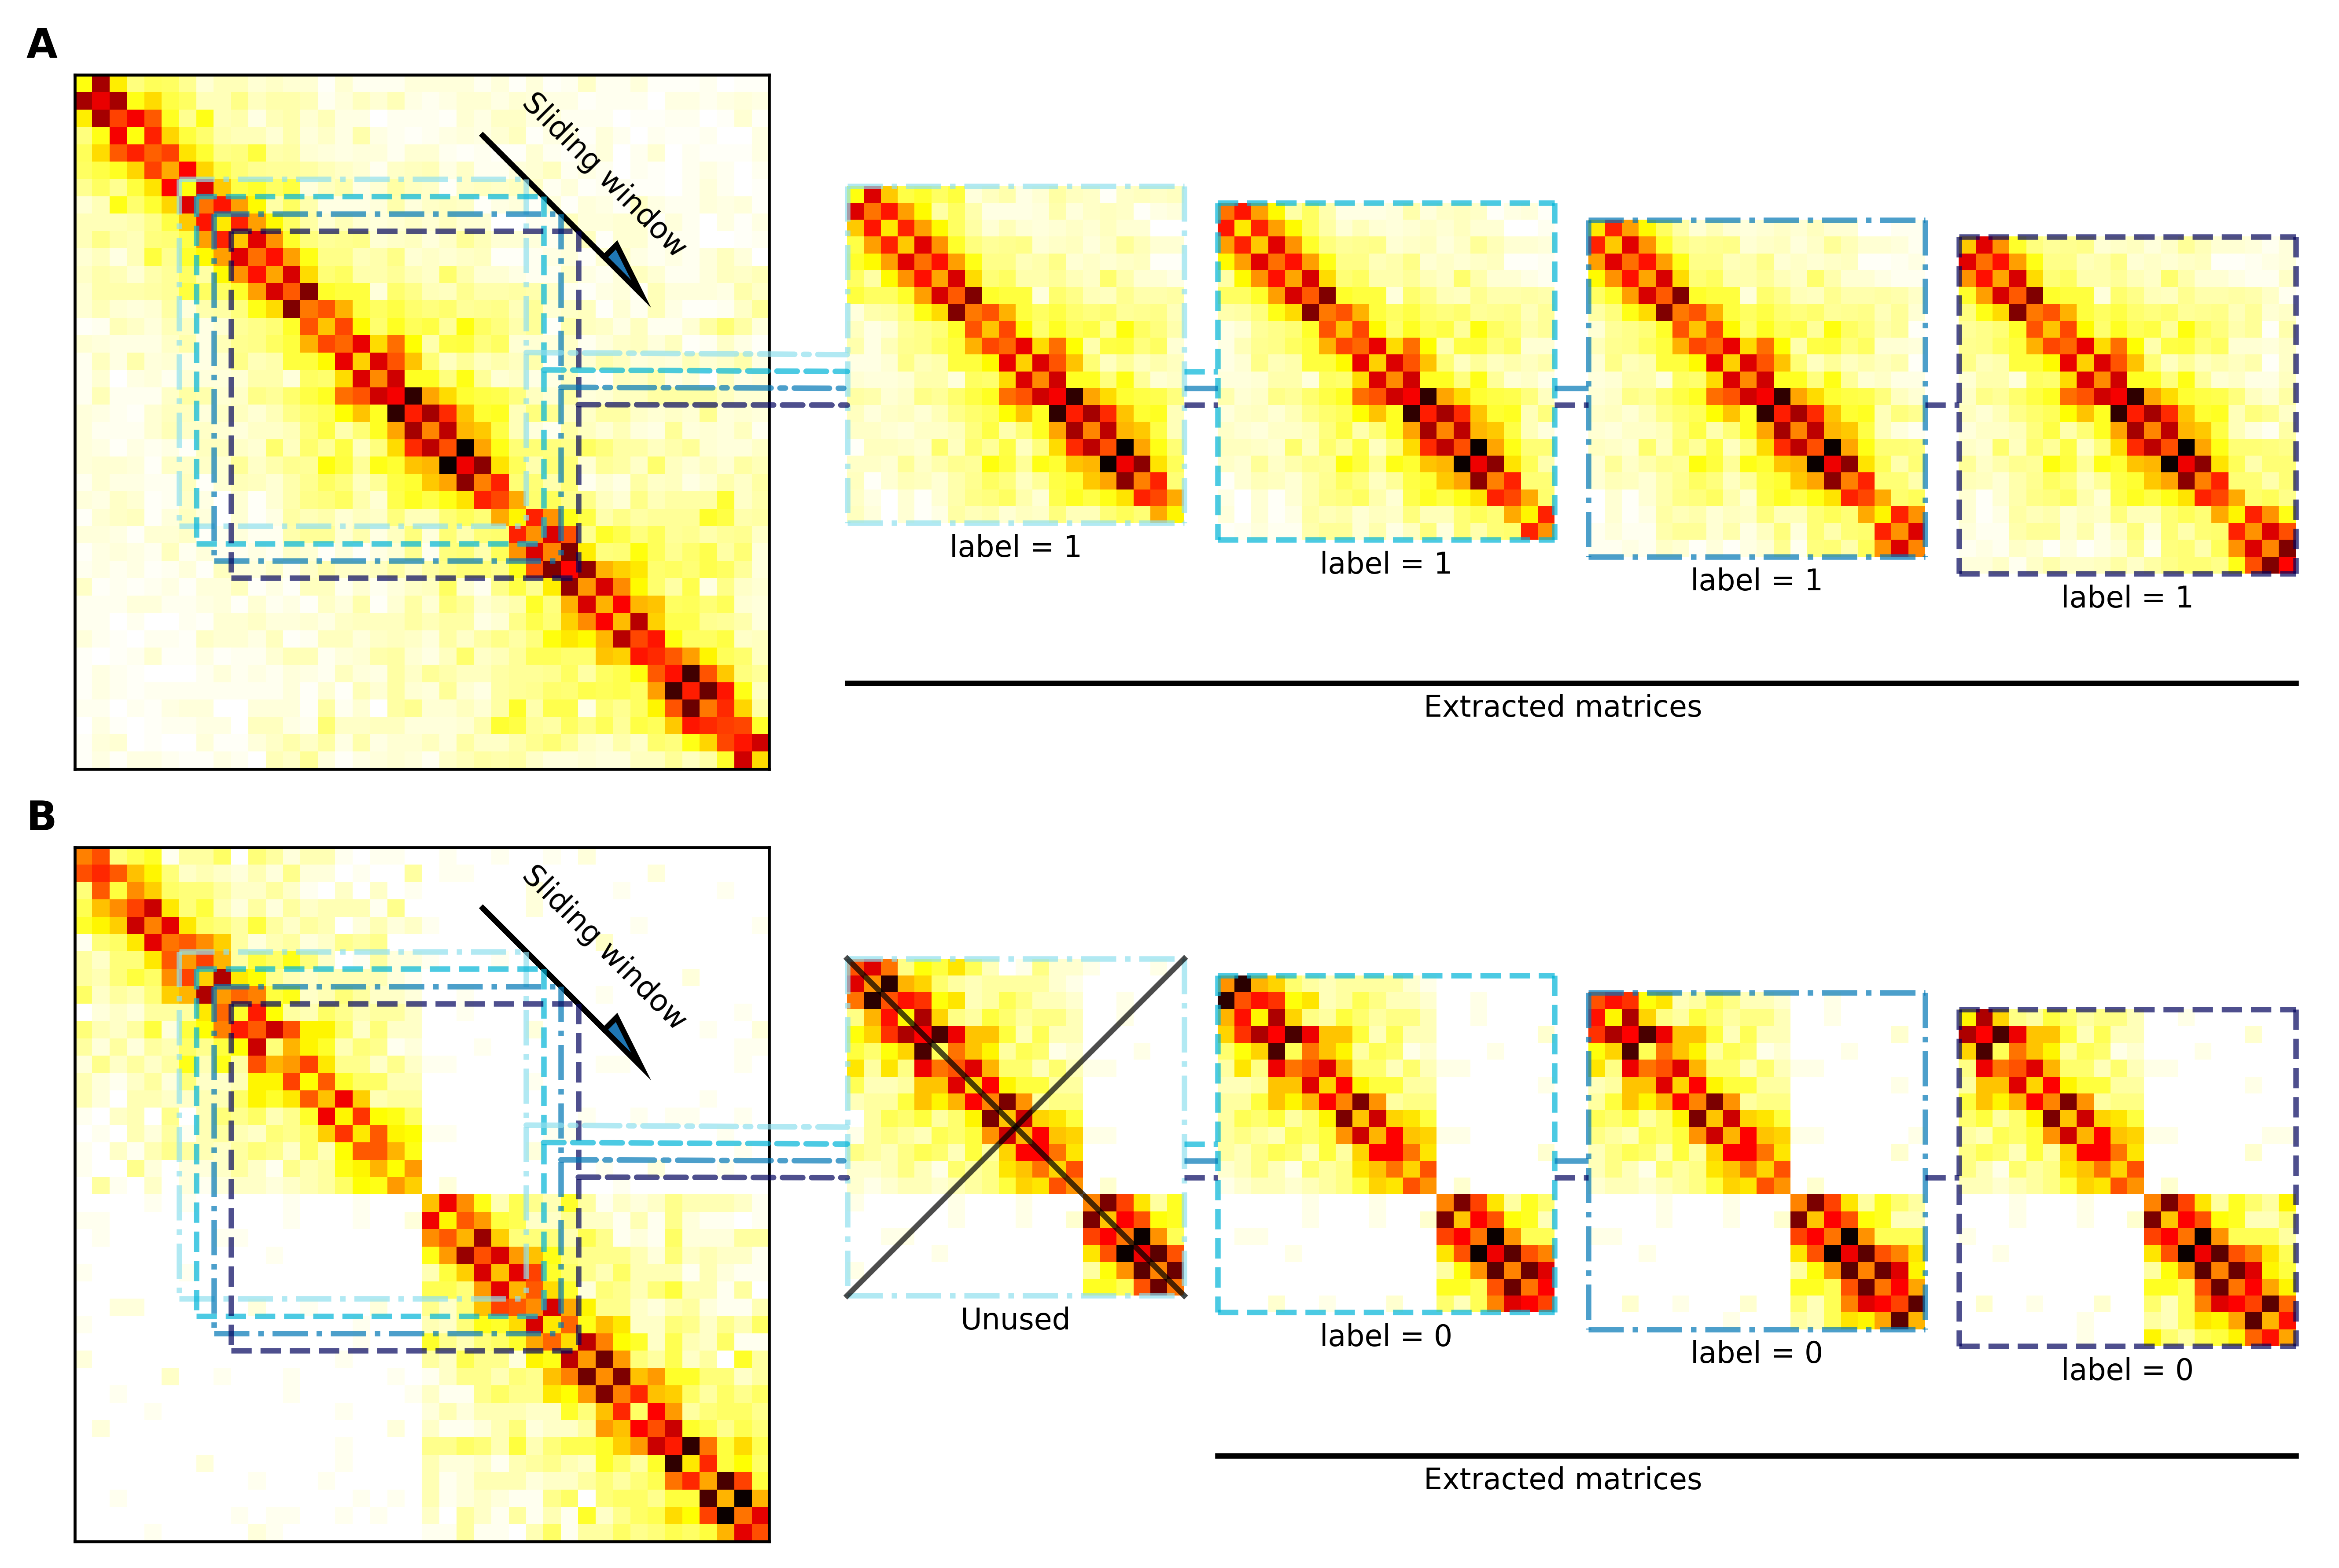

In [8]:

fig, axs = plt.subplots(2, 2, figsize=(9, 6), dpi=600, width_ratios=[0.333, 0.666], sharey='row')

lw = 1.5
fs = 8
colors=["#03045e", "#0077b6", "#00b4d8", "#90e0ef"][::-1] # SOURCE : https://coolors.co/palette/03045e-0077b6-00b4d8-90e0ef-caf0f8 
ys = [[1]*4, [1,0,0,0]]
bin_range = range(16, 20)

# Good matrix and chimeric matrix
cools, selections = [good_cool, err_cool], ["chr1_MATERNAL:10000000-10200000", 'contig_26:0-200000']
for K in range(2):
    ## Full mat
    mat = reconstruct_mat(selections[K], cools[K])
    axs[K, 0].matshow(mat, cmap="hot_r")
    axs[K, 0].tick_params(
            axis='both',          
            which='both',         
            bottom=False,         
            top=False,            
            left=False,           
            right=False,          
            labelbottom=False,    
            labeltop=False,       
            labelleft=False,      
            labelright=False      
        )
    
    ### Adding subzone
    linestyles = ["--", "dashdot", "--", "dashdot"] 
    for i, pos in enumerate(bin_range):
        start, end = pos-10, pos+10
        ls = linestyles.pop()
        axs[K, 0].plot([start-.5, end-.5], [start-.5, start-.5],
                        color=colors[i],
                        linestyle=ls,
                        linewidth=lw,
                        alpha=0.7
                    )
        axs[K, 0].plot([start-.5, end-.5], [end-.5, end-.5],
                        color=colors[i],
                        linestyle=ls,
                        linewidth=lw,
                        alpha=0.7
                    )
        axs[K, 0].plot([start-.5, start-.5], [start-.5, end-.5],
                        color=colors[i],
                        linestyle=ls,
                        linewidth=lw,
                        alpha=0.7
                    )
        axs[K, 0].plot([end-.5, end-.5], [start-.5, end-.5],
                        color=colors[i],
                        linestyle=ls,
                        linewidth=lw,
                        alpha=0.7
                    )
    
    ### Arrow and legend
    axs[K, 0].arrow(23, 3, 7, 7, lw=1.5, shape='left', head_width=2)
    axs[K, 0].text(30, 10, "Sliding window", color="black", fontsize=fs, ha="center", rotation=-45)

    ### Letter
    axs[K, 0].annotate(
            list(string.ascii_uppercase)[K],
            xy=(-0.07, 1.07),
            xycoords="axes fraction",
            fontsize=fs+3,
            fontweight="bold",
            color="black",
            va="top",
            ha="left",
        )
    
    ## Extracted mat
    inter_img=2
    xarr = [mat[pos-10:pos+10,pos-10:pos+10] for pos in bin_range]
    full_xarr = np.zeros((mat.shape[0], 4*20+3*inter_img+2))
    print(full_xarr.shape)
    
    xstart_end = []
    cur_pos=1
    for i, pos in enumerate(bin_range):
        xstart_end.append((pos-10, cur_pos))
        cur_pos += (20 + inter_img)
    
        full_xarr[xstart_end[-1][0]:xstart_end[-1][0]+20, xstart_end[-1][1]:xstart_end[-1][1]+20] = xarr[i]
    
    axs[K, 1].matshow(full_xarr, cmap="hot_r")
    axs[K, 1].axis('off')
    
    ### Adding borders
    linestyles = ["--", "dashdot", "--", "dashdot"][::-1]
    
    for i, (xstart, ystart) in enumerate(xstart_end):
        xend, yend = xstart+20, ystart+20
        axs[K, 1].plot([ystart-.5, ystart-.5], [xstart-.5, xend-.5],
                        color=colors[i],
                        linestyle=linestyles[i],
                        linewidth=lw,
                        alpha=0.7
                    )
        axs[K, 1].plot([yend-.5, yend-.5], [xstart-.5, xend-.5],
                        color=colors[i],
                        linestyle=linestyles[i],
                        linewidth=lw,
                        alpha=0.7
                    )
        axs[K, 1].plot([ystart-.5, yend-.5], [xstart-.5, xstart-.5], 
                        color=colors[i],
                        linestyle=linestyles[i],
                        linewidth=lw,
                        alpha=0.7
                    )
        axs[K, 1].plot([ystart-.5, yend-.5], [xend-.5, xend-.5], 
                        color=colors[i],
                        linestyle=linestyles[i],
                        linewidth=lw,
                        alpha=0.7
                    )
        # lines between panels
        if i >= 1:
            offset=0
            for k in range(i, 4):
                xstart2, ystart2 = xstart_end[k]
                axs[K, 1].plot([ystart-inter_img-.5, ystart-.5], [(xstart+10+offset)-.5, (xstart+10+offset)-.5],
                            color=colors[k],
                            linestyle=linestyles[k],
                            linewidth=lw,
                            alpha=0.7
                        )
                offset+=1
                
        # legends
        if K == 1 and ys[K][i] == 1: # Chimera matrix and label = 1 --> Not importing
            axs[K, 1].text(ystart+10-.5, xend+2-.5, f"Unused", fontsize=fs, ha="center")
            axs[K, 1].plot([ystart-.5, yend-.5], [xstart-.5, xend-.5],
                        color="black",
                        linestyle="-",
                        linewidth=lw,
                        alpha=0.7
                    )
            axs[K, 1].plot([ystart-.5, yend-.5], [xend-.5, xstart-.5],
                        color="black",
                        linestyle="-",
                        linewidth=lw,
                        alpha=0.7
                    )
        else:
            axs[K, 1].text(ystart+10-.5, xend+2-.5, f"label = {ys[K][i]}", fontsize=fs, ha="center")
    
    ### Big legend
    if K == 0:
        axs[K, 1].plot([1-.5, 87-.5], [35, 35], color="black", lw=lw, alpha=1)
    else:
        axs[K, 1].plot([23-.5, 87-.5], [35, 35], color="black", lw=lw, alpha=1)
    axs[K, 1].text(43, 37, "Extracted matrices", color="black", fontsize=fs, ha="center")
    
    ## Inter axes arrows
    linestyles = ["--", "dashdot", "--", "dashdot"][::-1] 
    for i, (xstart, ystart) in enumerate(xstart_end):
        xend, yend = xstart+20, ystart+20
        con = ConnectionPatch(
                        xyA=(xend-.5, xend-10-.5),
                        xyB=(1-.5, xend-10-0.5),
                        coordsA=axs[K, 0].transData,
                        coordsB=axs[K, 1].transData,
                        axesA=axs[K, 0],
                        axesB=axs[K, 1],
                        color=colors[i],
                        linestyle=linestyles[i],
                        linewidth=lw,
                        alpha=0.7
                    )
        fig.patches.append(con)

"""
# Inter matrices
imat = np.array(good_mat_big.fetch(("chr1_MATERNAL", None, None),("chr2_MATERNAL", None, None))).astype('float32')
np.divide(imat, np.quantile(imat, q=.9995), out=imat)
np.clip(imat, 0, 1, out=imat)
axs[2, 0].matshow(imat, cmap="hot_r")
axs[2, 0].set_xlim(right=140, left=60)
axs[2, 0].set_ylim(bottom=180, top=100)

## Adding selected patch
# x * (stride):x * (stride) + stride, y * (stride):y * (stride) + stride
for x, y in zip(bigP_idx[0], bigP_idx[1]):
    stride = 1000 * 5000 // 1000000
    x = convert_bin_2_bin(x * 1000, 5000, 1000000)
    y = convert_bin_2_bin(y * 1000, 5000, 1000000)
    ystart, yend, xstart, xend = x, x + stride, y, y + stride
    axs[2, 0].plot([xstart-.5, xend-.5], [ystart-.5, ystart-.5],
                    color=colors[i],
                    linestyle=ls,
                    linewidth=lw,
                    alpha=0.7
                )
    axs[2, 0].plot([xstart-.5, xend-.5], [yend-.5, yend-.5],
                    color=colors[i],
                    linestyle=ls,
                    linewidth=lw,
                    alpha=0.7
                )
    axs[2, 0].plot([xstart-.5, xstart-.5], [ystart-.5, yend-.5],
                    color=colors[i],
                    linestyle=ls,
                    linewidth=lw,
                    alpha=0.7
                )
    axs[2, 0].plot([xend-.5, xend-.5], [ystart-.5, yend-.5],
                    color=colors[i],
                    linestyle=ls,
                    linewidth=lw,
                    alpha=0.7
                )
"""

plt.tight_layout()
plt.savefig(f"SUPP.PAPER.Extraction.png")
plt.show()